# CNN Image Classification with PyTorch — FashionMNIST

This notebook trains a CNN on FashionMNIST and evaluates it on the standard test set and 10 custom smartphone images.

**Workflow:** FashionMNIST → preprocessing → CNN training → validation/test evaluation → confusion matrix → error analysis → custom image inference → confidence scores → metadata extraction.


In [1]:
# =========================
# Configuration
# =========================
GITHUB_USERNAME = "Im4an"
REPOSITORY_NAME = "AI-ML-Lab"
STUDENT_ID = "220116"

REPO_URL = f"https://github.com/{GITHUB_USERNAME}/{REPOSITORY_NAME}.git"
CLONE_DIR = "/content/cnn_assignment_repo"

BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

print("Repository:", REPO_URL)
print("Student ID:", STUDENT_ID)


Repository: https://github.com/Im4an/AI-ML-Lab.git
Student ID: 220116


## 1. Environment and automatic repository retrieval

The notebook is designed for Google Colab. It clones the GitHub repository automatically so that the custom phone images and saved model can be used without manual file upload.


In [2]:
import os
import sys
import math
import random
import shutil
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

repo_configured = (
    "YOUR_GITHUB_USERNAME" not in GITHUB_USERNAME
    and "YOUR_REPOSITORY_NAME" not in REPOSITORY_NAME
)

if IN_COLAB and repo_configured:
    if os.path.exists(CLONE_DIR):
        shutil.rmtree(CLONE_DIR)
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, CLONE_DIR], check=True)
    PROJECT_ROOT = Path(CLONE_DIR)
else:
    PROJECT_ROOT = Path.cwd()
    print("GitHub clone skipped. Configure the repository fields before final Colab submission.")

CUSTOM_DIR = PROJECT_ROOT / "CNN" / "Dataset"
MODEL_DIR = PROJECT_ROOT / "CNN" / "Model"
ASSET_DIR = PROJECT_ROOT / "CNN" / "report_assets"

CUSTOM_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ASSET_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / f"{STUDENT_ID}.pth"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("CUSTOM_DIR:", CUSTOM_DIR)
print("MODEL_PATH:", MODEL_PATH)


PROJECT_ROOT: /content/cnn_assignment_repo
CUSTOM_DIR: /content/cnn_assignment_repo/CNN/Dataset
MODEL_PATH: /content/cnn_assignment_repo/CNN/Model/220116.pth


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

from torchvision import datasets, transforms
from PIL import Image, ExifTags

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## 2. Dataset classes and preprocessing

FashionMNIST contains 10 grayscale classes at **28×28** pixels. Real phone photos, however, are much larger RGB images and often use a light wall/floor as the background.

To keep training and inference consistent, the **same transform pipeline** is applied to FashionMNIST and to the custom photos. A small polarity step checks the image border: when the border is predominantly light, the grayscale image is inverted so the object becomes light on a dark background, closer to the visual convention of FashionMNIST. Standard FashionMNIST images already have a dark background, so they normally remain unchanged.

Pipeline: **Grayscale → automatic background-polarity alignment → Resize(28×28) → ToTensor → Normalize**.

For one image, `ToTensor()` produces **[1, 28, 28]**. During inference, `unsqueeze(0)` adds the batch dimension, giving **[1, 1, 28, 28] = [N, C, H, W]** for `nn.Conv2d`.


In [4]:
from PIL import ImageOps, ImageStat

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

FMNIST_MEAN = (0.2860,)
FMNIST_STD = (0.3530,)

class AlignFashionMNISTPolarity:
    """Keep dark-background images; invert grayscale images with a light border."""
    def __call__(self, img):
        img = img.convert("L")
        w, h = img.size
        margin = max(1, min(w, h) // 12)
        strips = [
            img.crop((0, 0, w, margin)),
            img.crop((0, h - margin, w, h)),
            img.crop((0, 0, margin, h)),
            img.crop((w - margin, 0, w, h)),
        ]
        border_mean = sum(ImageStat.Stat(s).mean[0] for s in strips) / len(strips)
        return ImageOps.invert(img) if border_mean > 127 else img

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    AlignFashionMNISTPolarity(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD),
])

print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, name)


Classes:
0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


## 3. Automatic FashionMNIST download and DataLoaders


In [5]:
DATA_ROOT = "/content/fashionmnist_data" if IN_COLAB else "./fashionmnist_data"

full_train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, train=True, download=True, transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT, train=False, download=True, transform=transform
)

train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2 if IN_COLAB else 0, pin_memory=torch.cuda.is_available()
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2 if IN_COLAB else 0, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2 if IN_COLAB else 0, pin_memory=torch.cuda.is_available()
)

print(f"Training samples:   {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples:       {len(test_dataset)}")

x_batch, y_batch = next(iter(train_loader))
print("Example training batch shape:", x_batch.shape)  # [B, 1, 28, 28]


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 277kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.25MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]

Training samples:   54000
Validation samples: 6000
Test samples:       10000


Example training batch shape: torch.Size([64, 1, 28, 28])


## 4. CNN architecture

The model contains convolution, ReLU activation, max-pooling, dropout, and fully connected layers.


In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # [B, 32, 28, 28]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                 # [B, 32, 14, 14]

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # [B, 64, 14, 14]
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),                 # [B, 64, 7, 7]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = CNN(num_classes=len(CLASS_NAMES)).to(device)
print(model)

dummy = torch.randn(1, 1, 28, 28).to(device)
with torch.no_grad():
    dummy_out = model(dummy)
print("Input shape :", tuple(dummy.shape))
print("Output shape:", tuple(dummy_out.shape))


CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Input shape : (1, 1, 28, 28)
Output shape: (1, 10)


## 5. Loss function, optimizer, and training helpers


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            outputs = model(images)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

        preds = outputs.argmax(dim=1)
        total_loss += loss.item() * images.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += images.size(0)

    return total_loss / total_samples, total_correct / total_samples


## 6. Train the model or load saved weights

If `model/STUDENT_ID.pth` is already available in the cloned repository, it is loaded automatically. Otherwise, the model is trained and the state dictionary is saved.


In [8]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

loaded_saved_model = False

if MODEL_PATH.exists() and "YOUR_ID" not in STUDENT_ID:
    state = torch.load(MODEL_PATH, map_location=device)
    model.load_state_dict(state)
    loaded_saved_model = True
    print(f"Loaded saved model: {MODEL_PATH}")
else:
    print("Saved model not found (or STUDENT_ID not configured). Training from scratch...")

    best_val_acc = -1.0
    best_state = None

    for epoch in range(EPOCHS):
        train_loss, train_acc = run_epoch(
            model, train_loader, criterion, optimizer=optimizer
        )
        val_loss, val_acc = run_epoch(
            model, val_loader, criterion, optimizer=None
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"Epoch {epoch+1:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved best model to: {MODEL_PATH}")


Loaded saved model: /content/cnn_assignment_repo/CNN/Model/220116.pth


## 7. Training history plots

When the model is trained in the current run, two graphs are produced:
- Loss vs. Epochs
- Accuracy vs. Epochs

If saved weights are loaded, training history from the original run is not available unless separately saved.


In [9]:
if history["train_loss"]:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, history["train_loss"], marker="o", label="Training Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss vs Epochs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ASSET_DIR / "loss_vs_epochs.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(epochs, np.array(history["train_acc"]) * 100, marker="o", label="Training Accuracy")
    plt.plot(epochs, np.array(history["val_acc"]) * 100, marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("Accuracy vs Epochs")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(ASSET_DIR / "accuracy_vs_epochs.png", dpi=200)
    plt.show()
else:
    print("Saved model was loaded, so no new training-history curves were generated in this run.")


Saved model was loaded, so no new training-history curves were generated in this run.


## 8. Evaluation on the standard FashionMNIST test set


In [10]:
model.eval()

all_true = []
all_pred = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1)

        all_true.extend(labels.numpy().tolist())
        all_pred.extend(preds.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

test_accuracy = (all_true == all_pred).mean()
print(f"Standard test accuracy: {test_accuracy * 100:.2f}%")


Standard test accuracy: 91.90%


## 9. Confusion matrix


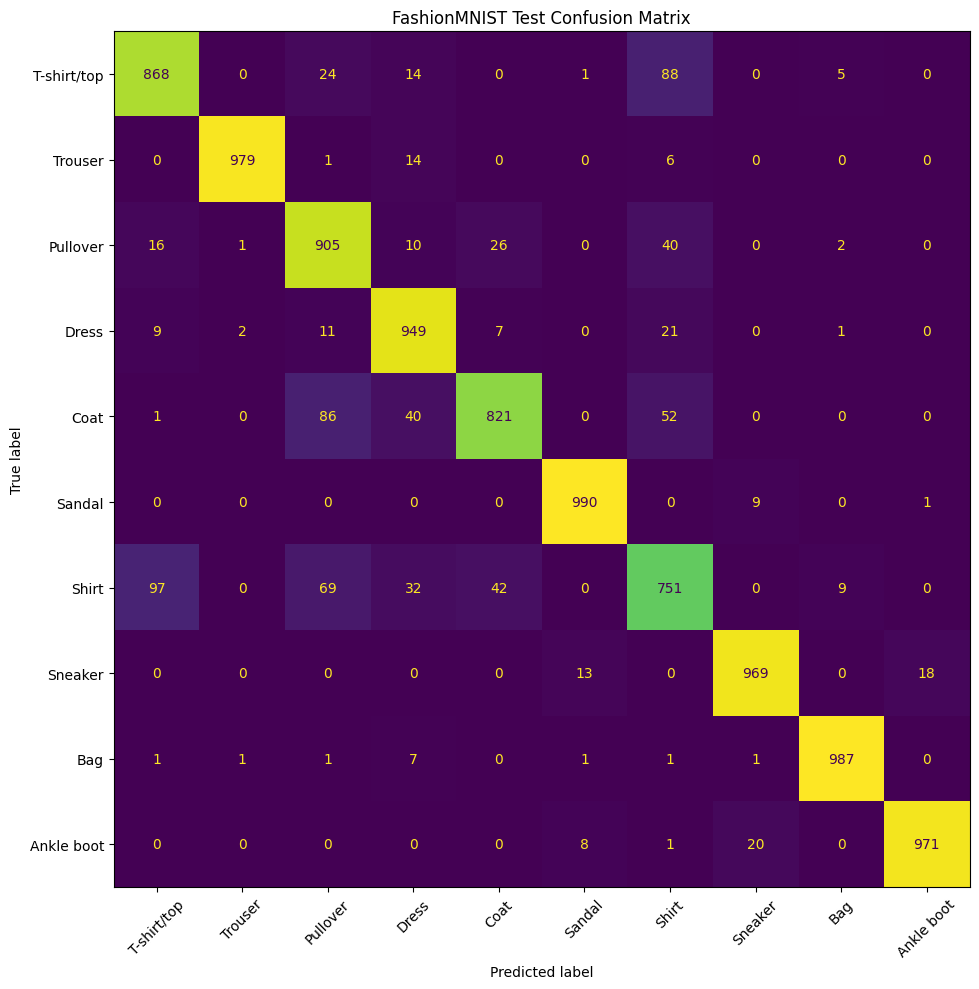

In [11]:
cm = confusion_matrix(all_true, all_pred, labels=list(range(10)))

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, values_format="d", colorbar=False)
plt.title("FashionMNIST Test Confusion Matrix")
plt.tight_layout()
plt.savefig(ASSET_DIR / "confusion_matrix.png", dpi=200)
plt.show()


## 10. Visual error analysis: three misclassified test images


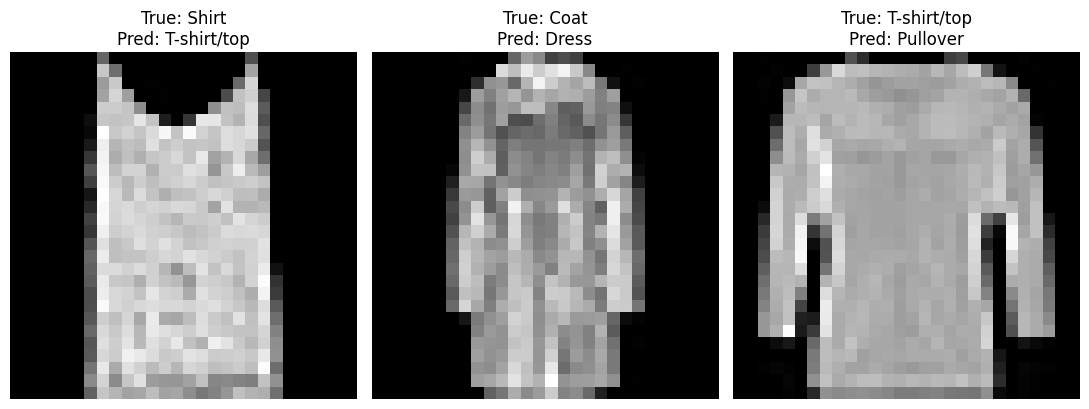

In [12]:
wrong_indices = np.where(all_true != all_pred)[0]

if len(wrong_indices) >= 3:
    rng = np.random.default_rng(RANDOM_SEED)
    chosen = rng.choice(wrong_indices, size=3, replace=False)

    fig, axes = plt.subplots(1, 3, figsize=(11, 4))

    for ax, idx in zip(axes, chosen):
        image, true_label = test_dataset[idx]

        display_img = image * FMNIST_STD[0] + FMNIST_MEAN[0]

        ax.imshow(display_img.squeeze(0), cmap="gray")
        ax.set_title(
            f"True: {CLASS_NAMES[true_label]}\n"
            f"Pred: {CLASS_NAMES[all_pred[idx]]}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(ASSET_DIR / "misclassified_examples.png", dpi=200)
    plt.show()
else:
    print("Fewer than three errors were found.")


## 11. Custom smartphone image discovery

Supported formats: JPG, JPEG, PNG, WEBP, BMP.

For final submission, exactly 10 real phone photos should be stored in the repository's `CNN/Dataset/` folder.


In [13]:
SUPPORTED_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

custom_files = sorted([
    p for p in CUSTOM_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTS
])

print(f"Found {len(custom_files)} custom image(s).")
for p in custom_files:
    print("-", p.name)

if len(custom_files) != 10:
    print(
        "\nFINAL SUBMISSION CHECK: the assignment requires 10 custom phone images. "
        "Add exactly 10 image files to CNN/Dataset/ before submitting."
    )


Found 10 custom image(s).
- ankleboot_01.png
- bag_01.png
- coat_01.png
- sandal_01.png
- shirt_01.png
- shirt_02.png
- sneaker_01.png
- trouser_01.png
- tshirt_01.png
- tshirt_02.png


## 12. Custom image preprocessing and dimension handling

Each phone image may begin with a large RGB dimension such as `[H, W, 3]`.

The inference pipeline performs:
- PIL loading
- grayscale conversion
- resize to `28×28`
- tensor conversion → `[1, 28, 28]`
- normalization using the same FashionMNIST mean/std
- batch dimension addition using `unsqueeze(0)` → `[1, 1, 28, 28]`

The final dimension order is `[N, C, H, W]`, which is the format expected by `nn.Conv2d`.


In [14]:
def preprocess_custom_image(image_path):
    original = Image.open(image_path)

    display_image = original.convert("RGB")

    processed = transform(original)      # [1, 28, 28]
    batched = processed.unsqueeze(0)     # [1, 1, 28, 28]

    return display_image, processed, batched

if custom_files:
    display_image, processed, batched = preprocess_custom_image(custom_files[0])
    print("Example file:", custom_files[0].name)
    print("Original PIL size (W, H):", display_image.size)
    print("After transform [C,H,W]:", tuple(processed.shape))
    print("After unsqueeze [N,C,H,W]:", tuple(batched.shape))


Example file: ankleboot_01.png
Original PIL size (W, H): (1086, 1448)
After transform [C,H,W]: (1, 28, 28)
After unsqueeze [N,C,H,W]: (1, 1, 28, 28)


## 13. Real-world prediction and confidence scores


In [15]:
TRUE_LABEL_MAP = {
    "tshirt": "T-shirt/top",
    "trouser": "Trouser",
    "pullover": "Pullover",
    "dress": "Dress",
    "coat": "Coat",
    "sandal": "Sandal",
    "shirt": "Shirt",
    "sneaker": "Sneaker",
    "bag": "Bag",
    "ankleboot": "Ankle boot",
}

def true_label_from_filename(path):
    prefix = path.stem.rsplit("_", 1)[0].lower()
    return TRUE_LABEL_MAP.get(prefix, "Unknown")

def predict_custom_image(image_path):
    display_image, processed, batched = preprocess_custom_image(image_path)
    batched = batched.to(device)

    model.eval()
    with torch.no_grad():
        logits = model(batched)
        probabilities = torch.softmax(logits, dim=1)
        confidence, pred_idx = torch.max(probabilities, dim=1)

    pred_idx = pred_idx.item()
    confidence = confidence.item()
    true_class = true_label_from_filename(image_path)

    return {
        "path": image_path,
        "display_image": display_image,
        "processed_tensor": processed,
        "true_class": true_class,
        "predicted_index": pred_idx,
        "predicted_class": CLASS_NAMES[pred_idx],
        "confidence": confidence,
        "correct": true_class == CLASS_NAMES[pred_idx],
    }

custom_results = [predict_custom_image(p) for p in custom_files]

for r in custom_results:
    print(
        f"{r['path'].name:25s} | True: {r['true_class']:12s} | "
        f"Pred: {r['predicted_class']:12s} | "
        f"Confidence: {r['confidence']*100:.2f}% | "
        f"{'Correct' if r['correct'] else 'Incorrect'}"
    )

if custom_results:
    custom_accuracy = np.mean([r["correct"] for r in custom_results])
    print(f"\nCustom phone-image accuracy: {custom_accuracy*100:.2f}%")


ankleboot_01.png          | True: Ankle boot   | Pred: Coat         | Confidence: 83.18% | Incorrect
bag_01.png                | True: Bag          | Pred: Bag          | Confidence: 73.15% | Correct
coat_01.png               | True: Coat         | Pred: Pullover     | Confidence: 46.10% | Incorrect
sandal_01.png             | True: Sandal       | Pred: Bag          | Confidence: 75.79% | Incorrect
shirt_01.png              | True: Shirt        | Pred: Bag          | Confidence: 95.04% | Incorrect
shirt_02.png              | True: Shirt        | Pred: Pullover     | Confidence: 40.60% | Incorrect
sneaker_01.png            | True: Sneaker      | Pred: Coat         | Confidence: 69.30% | Incorrect
trouser_01.png            | True: Trouser      | Pred: Trouser      | Confidence: 94.37% | Correct
tshirt_01.png             | True: T-shirt/top  | Pred: Pullover     | Confidence: 72.41% | Incorrect
tshirt_02.png             | True: T-shirt/top  | Pred: Shirt        | Confidence: 52.54% | Inco

## 14. Custom prediction gallery


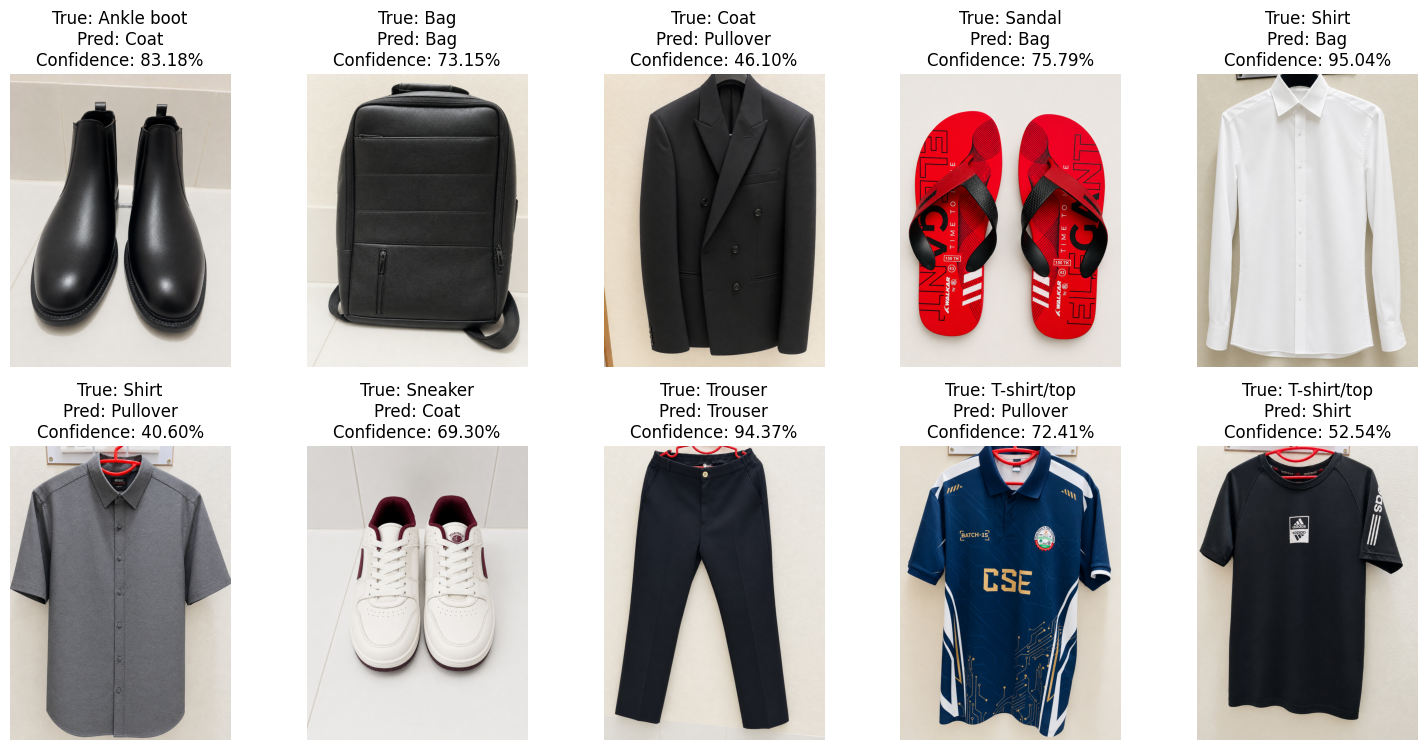

In [16]:
if custom_results:
    n = len(custom_results)
    cols = 5
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3.8 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, r in zip(axes, custom_results):
        ax.imshow(r["display_image"])
        ax.set_title(
            f"True: {r['true_class']}\n"
            f"Pred: {r['predicted_class']}\n"
            f"Confidence: {r['confidence']*100:.2f}%"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(ASSET_DIR / "custom_prediction_gallery.png", dpi=200)
    plt.show()
else:
    print("No custom images available yet. Add 10 phone photos to dataset/.")


## 15. Original vs processed custom image visualization

This figure is useful later in the LaTeX report to explain how a high-resolution phone photo is converted into the CNN-ready FashionMNIST format.


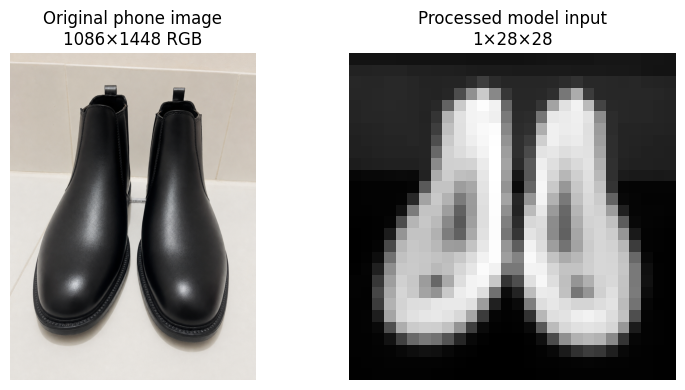

In [17]:
if custom_results:
    sample = custom_results[0]
    original = sample["display_image"]
    processed = sample["processed_tensor"]

    denorm = processed * FMNIST_STD[0] + FMNIST_MEAN[0]

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(original)
    axes[0].set_title(f"Original phone image\n{original.size[0]}×{original.size[1]} RGB")
    axes[0].axis("off")

    axes[1].imshow(denorm.squeeze(0), cmap="gray")
    axes[1].set_title("Processed model input\n1×28×28")
    axes[1].axis("off")

    plt.tight_layout()
    plt.savefig(ASSET_DIR / "original_vs_processed.png", dpi=200)
    plt.show()


## 16. Extract available metadata from the 10 phone photos

This section records only metadata that actually exists in each image. It does not invent missing EXIF values.


In [18]:
EXIF_TAGS = {v: k for k, v in ExifTags.TAGS.items()}

def safe_exif_value(value):
    if isinstance(value, bytes):
        return "<bytes>"
    try:
        return str(value)
    except Exception:
        return None

def extract_image_metadata(path):
    row = {
        "filename": path.name,
        "format": None,
        "width": None,
        "height": None,
        "mode": None,
        "file_size_kb": round(path.stat().st_size / 1024, 2),
        "device_make": None,
        "device_model": None,
        "datetime": None,
        "iso": None,
        "exposure_time": None,
        "focal_length": None,
    }

    with Image.open(path) as img:
        row["format"] = img.format
        row["width"], row["height"] = img.size
        row["mode"] = img.mode

        exif = img.getexif()
        if exif:
            named = {ExifTags.TAGS.get(k, k): v for k, v in exif.items()}
            row["device_make"] = safe_exif_value(named.get("Make"))
            row["device_model"] = safe_exif_value(named.get("Model"))
            row["datetime"] = safe_exif_value(
                named.get("DateTimeOriginal", named.get("DateTime"))
            )
            row["iso"] = safe_exif_value(
                named.get("ISOSpeedRatings", named.get("PhotographicSensitivity"))
            )
            row["exposure_time"] = safe_exif_value(named.get("ExposureTime"))
            row["focal_length"] = safe_exif_value(named.get("FocalLength"))

    return row

metadata_df = pd.DataFrame([extract_image_metadata(p) for p in custom_files])

if not metadata_df.empty:
    display(metadata_df)
    metadata_df.to_csv(ASSET_DIR / "custom_image_metadata.csv", index=False)
else:
    print("Metadata table will appear after custom images are added.")


,filename,format,width,height,mode,file_size_kb,device_make,device_model,datetime,iso,exposure_time,focal_length
0,ankleboot_01.png,PNG,1086,1448,RGB,1992.61,None,None,None,None,None,None
1,bag_01.png,PNG,1086,1448,RGB,2846.11,None,None,None,None,None,None
2,coat_01.png,PNG,1086,1448,RGB,2050.93,None,None,None,None,None,None
3,sandal_01.png,PNG,1086,1448,RGB,2047.73,None,None,None,None,None,None
4,shirt_01.png,PNG,1086,1448,RGB,1763.86,None,None,None,None,None,None
5,shirt_02.png,PNG,1086,1448,RGB,2975.32,None,None,None,None,None,None
6,sneaker_01.png,PNG,1086,1448,RGB,1860.71,None,None,None,None,None,None
7,trouser_01.png,PNG,1086,1448,RGB,2115.13,None,None,None,None,None,None
8,tshirt_01.png,PNG,1086,1448,RGB,2022.65,None,None,None,None,None,None
9,tshirt_02.png,PNG,1086,1448,RGB,2364.64,None,None,None,None,None,None


## 17. Final automated submission check


In [19]:
checks = {
    "GitHub configuration edited": repo_configured,
    "FashionMNIST loaded": len(test_dataset) > 0,
    "CNN defined": isinstance(model, nn.Module),
    "Model weights available locally": MODEL_PATH.exists(),
    "Exactly 10 custom images": len(custom_files) == 10,
    "Custom predictions produced": len(custom_results) == 10,
}

print("FINAL CHECK")
print("=" * 50)
for name, ok in checks.items():
    print(f"{'PASS' if ok else 'FIX ':4s} | {name}")

if all(checks.values()):
    print("\nEverything required by this automated workflow is ready.")
else:
    print("\nComplete the items marked FIX before final submission.")


FINAL CHECK
PASS | GitHub configuration edited
PASS | FashionMNIST loaded
PASS | CNN defined
PASS | Model weights available locally
PASS | Exactly 10 custom images
PASS | Custom predictions produced

Everything required by this automated workflow is ready.


# End of notebook

For final submission, confirm that:
- the repository is public,
- all 10 custom phone images are in `dataset/`,
- the trained `.pth` file is in `CNN/Model/`,
- the notebook is in the repository,
- **Run All** works without manual upload or broken file paths,
- the GitHub and Colab links are submitted.
